In [1]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Data Analysis

In [2]:
# import excel sheets
xls = pd.ExcelFile('Dataset.xlsx')

print(xls.sheet_names)

['items_names', 'user_data', 'training_log', 'body_log', 'purchase', 'item_names']


In [3]:
df_usr=pd.read_excel(xls, sheet_name="user_data")
df_trn=pd.read_excel(xls, sheet_name="training_log")
df_bdy=pd.read_excel(xls, sheet_name="body_log")

In [4]:
## check the length of each df
print(len(df_usr))
print(len(df_trn))
print(len(df_bdy))

200
200
200


In [5]:
## heading the first five entries
print(df_usr.head())
print(df_trn.head())
print(df_bdy.head())

   user_id  age  sex  area registration_date  membership_renewal  \
0        1   29    1     3        2024-01-04                   0   
1        2   32    2     8        2024-01-04                   1   
2        3   30    1     5        2024-01-04                   0   
3        4   29    2     3        2024-01-04                   0   
4        5   24    1     8        2024-01-04                   0   

   total_purchase  aim  
0               0    1  
1            4780    2  
2            4780    3  
3               0    2  
4            1900    1  
   user_id  aerobic_excercise  calorie_cut  mentorship  nr_of_gym_visit  \
0        1         335.082824         20.0         0.0                4   
1        2        1600.000000        200.0         1.0                8   
2        3         380.559631          2.0         1.0                8   
3        4         699.763166          1.0         1.0                4   
4        5         484.871381         44.0         0.0            

In [6]:
# concatenate entries
df_con=pd.concat([df_usr,df_trn.loc[:, df_trn.columns != 'user_id'], df_bdy.loc[:, df_bdy.columns != 'user_id']], axis=1)

In [7]:
df_con

,user_id,age,sex,area,registration_date,membership_renewal,total_purchase,aim,aerobic_excercise,calorie_cut,mentorship,nr_of_gym_visit,total_time_in_gym,body_weight,body_fat,muscle_mass
0,1,29,1,3,2024-01-04,0,0,1,335.082824,20.0,0.0,4,468,0.562831,0.004389,-0.352464
1,2,32,2,8,2024-01-04,1,4780,2,1600.000000,200.0,1.0,8,880,-0.055478,-0.010000,0.248310
2,3,30,1,5,2024-01-04,0,4780,3,380.559631,2.0,1.0,8,1072,1.038801,0.005267,0.239278
3,4,29,2,3,2024-01-04,0,0,2,699.763166,1.0,1.0,4,396,0.913511,-0.000774,0.058059
4,5,24,1,8,2024-01-04,0,1900,1,484.871381,44.0,0.0,8,776,0.059202,0.005093,0.182056
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,24,2,8,2024-03-30,0,1900,2,762.949694,27.0,0.0,8,840,-0.029638,0.005138,-0.122330
196,197,31,2,5,2024-03-30,0,1900,2,733.415806,4.0,0.0,4,508,-0.113744,0.009864,-0.025370
197,198,29,1,3,2024-03-31,1,17180,1,522.263410,35.0,1.0,12,1608,-0.295031,-0.002670,0.500000
198,199,23,1,5,2024-03-31,0,1900,1,233.531440,7.0,0.0,4,504,0.176865,0.008567,0.143348


In [8]:
# calculate the correlation, pearson
df_con.corr()

,user_id,age,sex,area,registration_date,membership_renewal,total_purchase,aim,aerobic_excercise,calorie_cut,mentorship,nr_of_gym_visit,total_time_in_gym,body_weight,body_fat,muscle_mass
user_id,1.000000,-0.035970,0.013014,-0.007693,0.998800,0.024190,0.008307,0.050709,-0.040493,0.040435,0.023479,-0.036597,-0.029178,-0.082696,0.020461,0.142172
age,-0.035970,1.000000,0.013483,0.009647,-0.034306,-0.012625,0.078695,-0.068129,0.006917,-0.031430,-0.027638,0.044436,0.048669,-0.055463,-0.003303,0.067079
sex,0.013014,0.013483,1.000000,0.032826,0.012135,0.048095,-0.022222,0.395331,0.086367,0.346896,-0.018930,0.044027,0.017856,0.071295,-0.101258,-0.172634
area,-0.007693,0.009647,0.032826,1.000000,-0.009485,0.012922,-0.090948,-0.056749,0.041351,0.090169,-0.127956,-0.022800,-0.033852,-0.029580,0.015432,-0.100273
registration_date,0.998800,-0.034306,0.012135,-0.009485,1.000000,0.023605,0.007014,0.051853,-0.041679,0.038327,0.024455,-0.037493,-0.030224,-0.082665,0.021168,0.142535
membership_renewal,0.024190,-0.012625,0.048095,0.012922,0.023605,1.000000,0.608875,0.026076,0.644926,0.561254,0.234377,0.676235,0.677138,-0.277841,-0.107080,0.272536
total_purchase,0.008307,0.078695,-0.022222,-0.090948,0.007014,0.608875,1.000000,0.022660,0.614886,0.180878,0.226905,0.847084,0.873740,-0.285533,-0.070268,0.104182
aim,0.050709,-0.068129,0.395331,-0.056749,0.051853,0.026076,0.022660,1.000000,0.358890,0.050727,0.026816,-0.006733,0.007714,-0.254287,0.105005,-0.241759
aerobic_excercise,-0.040493,0.006917,0.086367,0.041351,-0.041679,0.644926,0.614886,0.358890,1.000000,0.379379,0.142792,0.581079,0.585751,-0.517476,-0.066820,-0.109711
calorie_cut,0.040435,-0.031430,0.346896,0.090169,0.038327,0.561254,0.180878,0.050727,0.379379,1.000000,0.012880,0.235177,0.222557,0.043475,-0.126359,-0.053496


<Axes: >

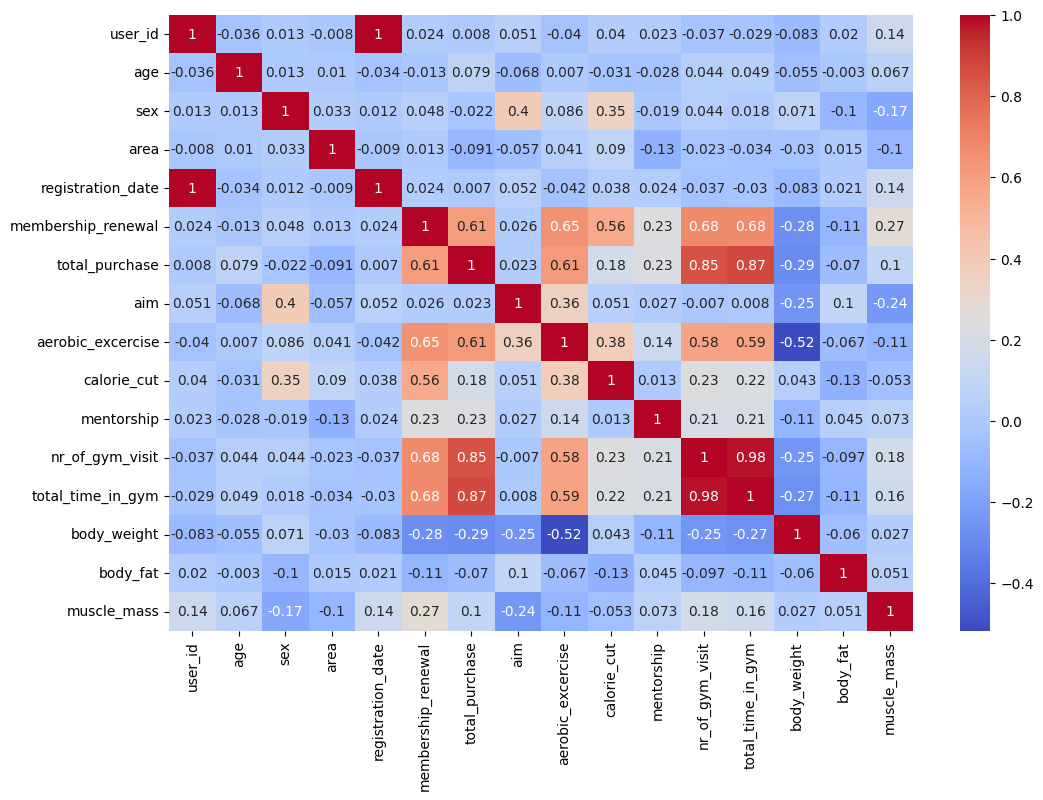

In [9]:
## write out the matrix as a figure
plt.figure(figsize=(12, 8))
sns.heatmap(df_con.corr().round(3), annot=True, cmap="coolwarm")

## Plotting individually to add more information

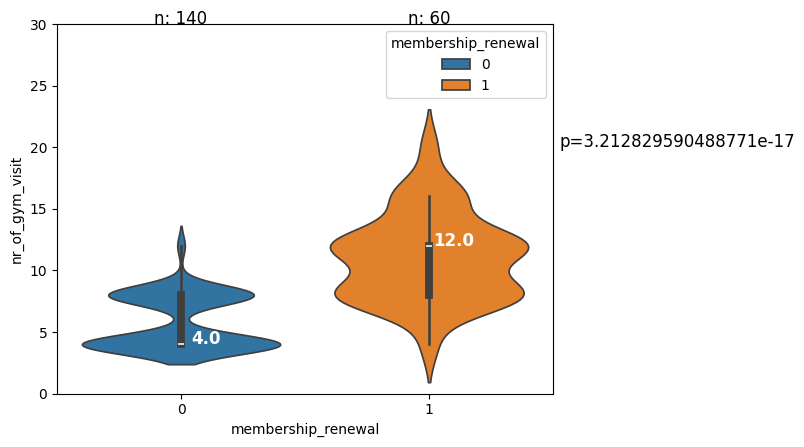

In [11]:
from scipy import stats
ax=sns.violinplot(data=df_con[['membership_renewal', 'nr_of_gym_visit']], x='membership_renewal', y= 'nr_of_gym_visit', hue='membership_renewal')
plt.ylim(0,30)

# Calculate number of obs per group & median to position labels
medians = df_con.groupby(['membership_renewal'])['nr_of_gym_visit'].median().values
nobs = df_con['membership_renewal'].value_counts().values
nobs = [str(x) for x in nobs.tolist()]
nobs = ["n: " + i for i in nobs]

# separate df for t-test
a1=df_con['nr_of_gym_visit'].loc[df_con['membership_renewal'] ==0]
a2=df_con['nr_of_gym_visit'].loc[df_con['membership_renewal'] ==1]
t_test=stats.ttest_ind(a1, a2, equal_var=False)
pval=t_test[1]
pval='p='+str(t_test[1])
 
# Add it to the plot
pos = range(len(nobs))
for tick,label in zip(pos,ax.get_xticklabels()):
    ax.text(pos[tick]+0.1,
            medians[tick],
            medians[tick],
            horizontalalignment='center',
            size='large',
            color='w',
            weight='semibold')
    ax.text(pos[tick],
            30,
            nobs[tick],
            horizontalalignment='center',
            size='large')
           # weight='semibold')
ax.text(pos[tick]+1,
        20,
        pval,
        horizontalalignment='center',
        size='large')
        #weight='semibold')

plt.show()

In [ ]:
## membership_renewal=0: did not renew membership after 30 days
## membership_renewal=1: renewed membership after 30 days

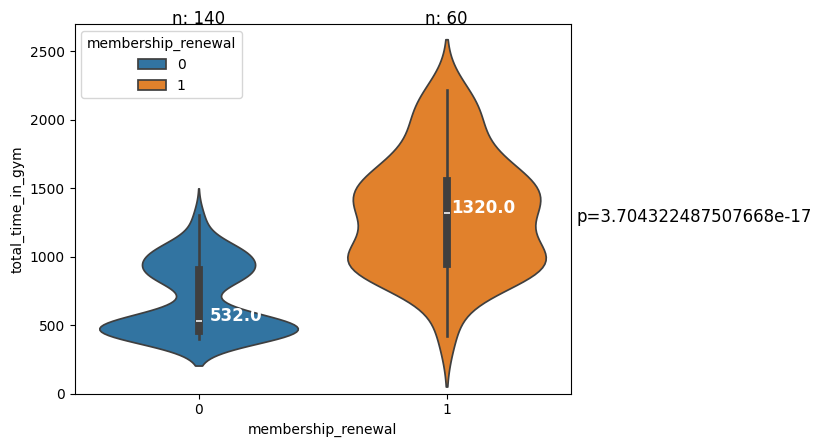

In [13]:
ax=sns.violinplot(data=df_con[['membership_renewal', 'total_time_in_gym']], x='membership_renewal', y= 'total_time_in_gym', hue='membership_renewal')
plt.ylim(0,2700)

# Calculate number of obs per group & median to position labels
medians = df_con.groupby(['membership_renewal'])['total_time_in_gym'].median().values
nobs = df_con['membership_renewal'].value_counts().values
nobs = [str(x) for x in nobs.tolist()]
nobs = ["n: " + i for i in nobs]

# separate df for t-test
a1=df_con['total_time_in_gym'].loc[df_con['membership_renewal'] ==0]
a2=df_con['total_time_in_gym'].loc[df_con['membership_renewal'] ==1]
t_test=stats.ttest_ind(a1, a2, equal_var=False)
pval=t_test[1]
pval='p='+str(t_test[1])

# Add it to the plot
pos = range(len(nobs))
for tick,label in zip(pos,ax.get_xticklabels()):
    ax.text(pos[tick]+0.15,
            medians[tick],
            medians[tick],
            horizontalalignment='center',
            size='large',
            color='w',
            weight='semibold')
    ax.text(pos[tick],
            2700,
            nobs[tick],
            horizontalalignment='center',
            size='large')
           # weight='semibold')
ax.text(pos[tick]+1,
        1250,
        pval,
        horizontalalignment='center',
        size='large')
       # weight='semibold')

plt.show()

In [ ]:
## plotting in one figure

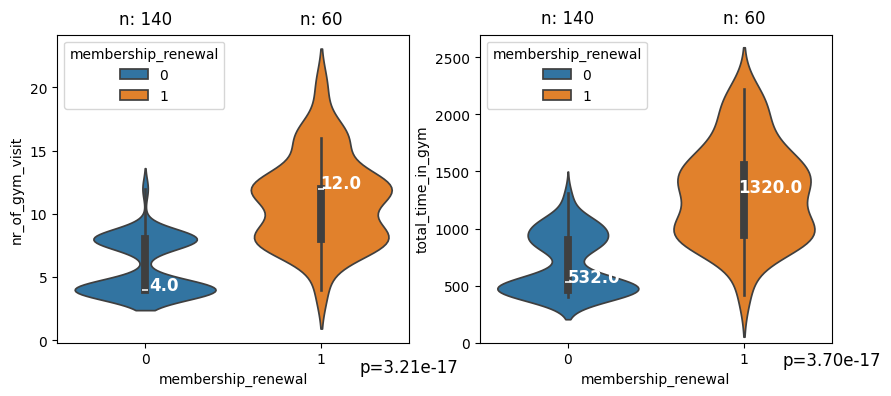

In [52]:
from scipy import stats
fig, ax= plt.subplots(1,2, figsize=(10,4))
sns.violinplot(data=df_con[['membership_renewal', 'nr_of_gym_visit']], x='membership_renewal', y= 'nr_of_gym_visit', 
               hue='membership_renewal', ax=ax[0])
plt.ylim(0,30)

# Calculate number of obs per group & median to position labels
medians = df_con.groupby(['membership_renewal'])['nr_of_gym_visit'].median().values
nobs = df_con['membership_renewal'].value_counts().values
nobs = [str(x) for x in nobs.tolist()]
nobs = ["n: " + i for i in nobs]

# separate df for t-test
a1=df_con['nr_of_gym_visit'].loc[df_con['membership_renewal'] ==0]
a2=df_con['nr_of_gym_visit'].loc[df_con['membership_renewal'] ==1]
t_test=stats.ttest_ind(a1, a2, equal_var=False)
pval=t_test[1]
pval=f"p={pval:.2e}"
 
# Add it to the plot
pos = range(len(nobs))
for tick,label in zip(pos,ax[0].get_xticklabels()):
    ax[0].text(pos[tick]+0.11,
            medians[tick],
            medians[tick],
            horizontalalignment='center',
            size='large',
            color='w',
            weight='semibold')
    ax[0].text(pos[tick],
            25,
            nobs[tick],
            horizontalalignment='center',
            size='large')
           # weight='semibold')
ax[0].text(pos[tick]+0.5,
           -2.5,
           pval,
           horizontalalignment='center',
           size='large')
        #weight='semibold')

sns.violinplot(data=df_con[['membership_renewal', 'total_time_in_gym']], x='membership_renewal', y= 'total_time_in_gym', 
               hue='membership_renewal', ax=ax[1])
plt.ylim(0,2700)

# Calculate number of obs per group & median to position labels
medians = df_con.groupby(['membership_renewal'])['total_time_in_gym'].median().values
nobs = df_con['membership_renewal'].value_counts().values
nobs = [str(x) for x in nobs.tolist()]
nobs = ["n: " + i for i in nobs]

# separate df for t-test
a1=df_con['total_time_in_gym'].loc[df_con['membership_renewal'] ==0]
a2=df_con['total_time_in_gym'].loc[df_con['membership_renewal'] ==1]
t_test=stats.ttest_ind(a1, a2, equal_var=False)
pval=t_test[1]
pval=f"p={pval:.2e}"

# Add it to the plot
pos = range(len(nobs))
for tick,label in zip(pos,ax[1].get_xticklabels()):
    ax[1].text(pos[tick]+0.15,
            medians[tick],
            medians[tick],
            horizontalalignment='center',
            size='large',
            color='w',
            weight='semibold')
    ax[1].text(pos[tick],
            2800,
            nobs[tick],
            horizontalalignment='center',
            size='large')
           # weight='semibold')
ax[1].text(pos[tick]+0.5,
           -200,
           pval,
           horizontalalignment='center',
           size='large')
       # weight='semibold')

plt.show()

## Analysis with other 

In [32]:
df_con['aerobic_excercise(kcal/min)']=df_con['aerobic_excercise']/df_con['total_time_in_gym']

In [33]:
df_con['aerobic_excercise(kcal/min)']

0      0.715989
1      1.818182
2      0.355000
3      1.767079
4      0.624834
         ...   
195    0.908273
196    1.443732
197    0.324791
198    0.463356
199    0.021558
Name: aerobic_excercise(kcal/min), Length: 200, dtype: float64

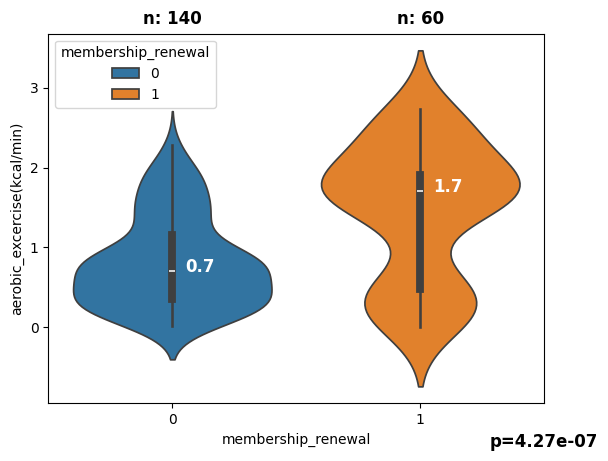

In [54]:
ax=sns.violinplot(data=df_con[['membership_renewal', 'aerobic_excercise(kcal/min)']],
                  x='membership_renewal', y= 'aerobic_excercise(kcal/min)', hue='membership_renewal')

# Calculate number of obs per group & median to position labels
medians = df_con.groupby(['membership_renewal'])['aerobic_excercise(kcal/min)'].median().values.round(1)
nobs = df_con['membership_renewal'].value_counts().values
nobs = [str(x) for x in nobs.tolist()]
nobs = ["n: " + i for i in nobs]

# separate df for t-test
a1=df_con['aerobic_excercise(kcal/min)'].loc[df_con['membership_renewal'] ==0]
a2=df_con['aerobic_excercise(kcal/min)'].loc[df_con['membership_renewal'] ==1]
t_test=stats.ttest_ind(a1, a2, equal_var=False)
pval=t_test[1]
pval=f"p={pval:.2e}"


# Add it to the plot
pos = range(len(nobs))
for tick,label in zip(pos,ax.get_xticklabels()):
    ax.text(pos[tick]+0.11,
            medians[tick],
            medians[tick],
            horizontalalignment='center',
            size='large',
            color='w',
            weight='semibold')
    ax.text(pos[tick],
            3.8,
            nobs[tick],
            horizontalalignment='center',
            size='large',
            weight='semibold')
ax.text(pos[tick]+0.5,
        -1.5,
        pval,
        horizontalalignment='center',
        size='large',
        weight='semibold')

plt.show()

## Check the average calories lost by aerobic (per visit)

In [37]:
df_con['aerobic_excercise(kcal/visit)']=df_con['aerobic_excercise']/df_con['nr_of_gym_visit']
df_con['aerobic_excercise(kcal/visit)']

0       83.770706
1      200.000000
2       47.569954
3      174.940791
4       60.608923
          ...    
195     95.368712
196    183.353951
197     43.521951
198     58.382860
199      2.543800
Name: aerobic_excercise(kcal/visit), Length: 200, dtype: float64

In [41]:
df_con['stay_time_per_visit']=df_con['total_time_in_gym']/df_con['nr_of_gym_visit']

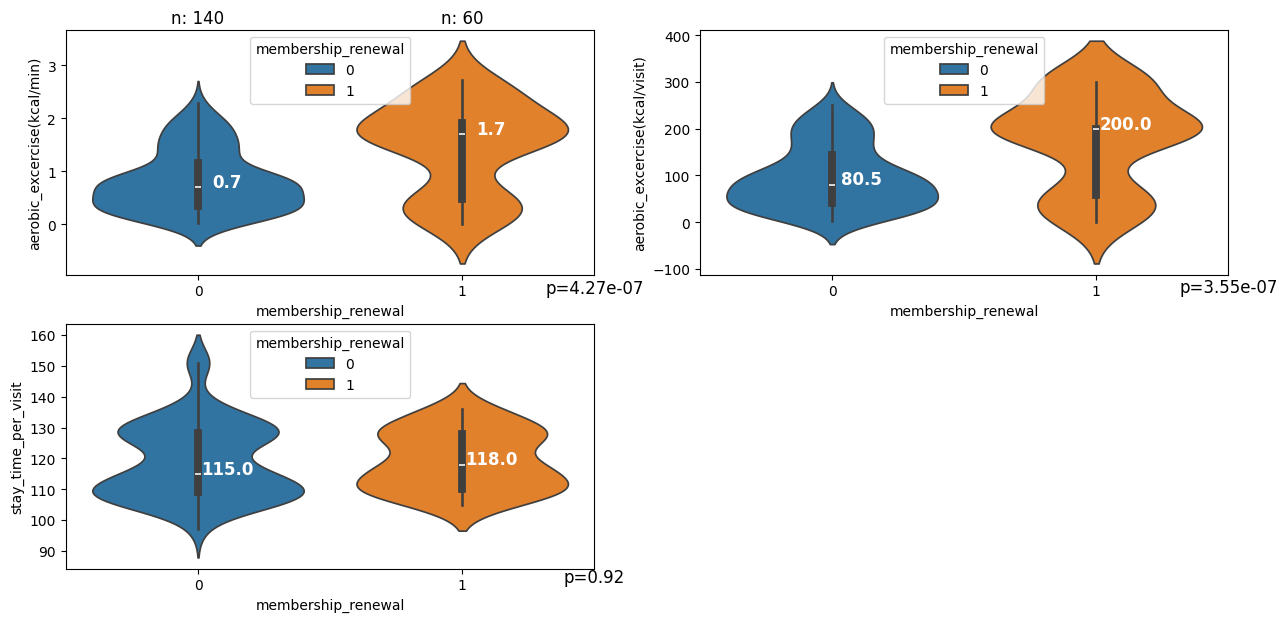

In [55]:
fig,ax=plt.subplots(2,2, figsize=(15,7))
sns.violinplot(data=df_con[['membership_renewal', 'aerobic_excercise(kcal/min)']],
               x='membership_renewal', y= 'aerobic_excercise(kcal/min)', hue='membership_renewal', ax=ax[0,0])

# Calculate number of obs per group & median to position labels
medians = df_con.groupby(['membership_renewal'])['aerobic_excercise(kcal/min)'].median().values.round(1)
nobs = df_con['membership_renewal'].value_counts().values
nobs = [str(x) for x in nobs.tolist()]
nobs = ["n: " + i for i in nobs]

# separate df for t-test
a1=df_con['aerobic_excercise(kcal/min)'].loc[df_con['membership_renewal'] ==0]
a2=df_con['aerobic_excercise(kcal/min)'].loc[df_con['membership_renewal'] ==1]
t_test=stats.ttest_ind(a1, a2, equal_var=False)
pval=t_test[1]
pval=f"p={pval:.2e}"


# Add it to the plot
pos = range(len(nobs))
for tick,label in zip(pos,ax[0,0].get_xticklabels()):
    ax[0,0].text(pos[tick]+0.11,
            medians[tick],
            medians[tick],
            horizontalalignment='center',
            size='large',
            color='w',
            weight='semibold')
    ax[0,0].text(pos[tick],
            3.8,
            nobs[tick],
            horizontalalignment='center',
            size='large')
           # weight='semibold')
ax[0,0].text(pos[tick]+0.5,
        -1.3,
        pval,
        horizontalalignment='center',
        size='large')
        #weight='semibold')



sns.violinplot(data=df_con[['membership_renewal', 'aerobic_excercise(kcal/visit)']],
               x='membership_renewal', y= 'aerobic_excercise(kcal/visit)', hue='membership_renewal', ax=ax[0,1])

# Calculate number of obs per group & median to position labels
medians = df_con.groupby(['membership_renewal'])['aerobic_excercise(kcal/visit)'].median().values.round(1)
nobs = df_con['membership_renewal'].value_counts().values
nobs = [str(x) for x in nobs.tolist()]
nobs = ["n: " + i for i in nobs]

# separate df for t-test
a1=df_con['aerobic_excercise(kcal/visit)'].loc[df_con['membership_renewal'] ==0]
a2=df_con['aerobic_excercise(kcal/visit)'].loc[df_con['membership_renewal'] ==1]
t_test=stats.ttest_ind(a1, a2, equal_var=False)
pval=t_test[1]
pval=f"p={pval:.2e}"

# Add it to the plot
pos = range(len(nobs))
for tick,label in zip(pos,ax[0,1].get_xticklabels()):
    ax[0,1].text(pos[tick]+0.11,
            medians[tick],
            medians[tick],
            horizontalalignment='center',
            size='large',
            color='w',
            weight='semibold')
#    ax[0,1].text(pos[tick],
#            420,
#            nobs[tick],
#            horizontalalignment='center',
#            size='large',
#            weight='semibold')
ax[0,1].text(pos[tick]+0.5,
        -150,
        pval,
        horizontalalignment='center',
        size='large')
       # weight='semibold')

sns.violinplot(data=df_con[['membership_renewal', 'stay_time_per_visit']], x='membership_renewal', y= 'stay_time_per_visit', hue='membership_renewal', ax=ax[1,0])

# Calculate number of obs per group & median to position labels
medians = df_con.groupby(['membership_renewal'])['stay_time_per_visit'].median().values.round(1)
nobs = df_con['membership_renewal'].value_counts().values
nobs = [str(x) for x in nobs.tolist()]
nobs = ["n: " + i for i in nobs]
 
# separate df for t-test
a1=df_con['stay_time_per_visit'].loc[df_con['membership_renewal'] ==0]
a2=df_con['stay_time_per_visit'].loc[df_con['membership_renewal'] ==1]
t_test=stats.ttest_ind(a1, a2, equal_var=False)
pval=t_test[1]
pval=f"p={pval.round(2)}"

# Add it to the plot
pos = range(len(nobs))
for tick,label in zip(pos,ax[1,0].get_xticklabels()):
    ax[1,0].text(pos[tick]+0.11,
            medians[tick],
            medians[tick],
            horizontalalignment='center',
            size='large',
            color='w',
            weight='semibold')
 #   ax[1,0].text(pos[tick],
  #          170,
    #        nobs[tick],
     #       horizontalalignment='center',
        #    size='large',
         #   weight='semibold')
ax[1,0].text(pos[tick]+0.5,
        80,
        pval,
        horizontalalignment='center',
        size='large')
       # weight='semibold')
ax[1,1].remove()
plt.show()

# Analysis on purchase history

Text(2000, 20000, 'r=0.87')

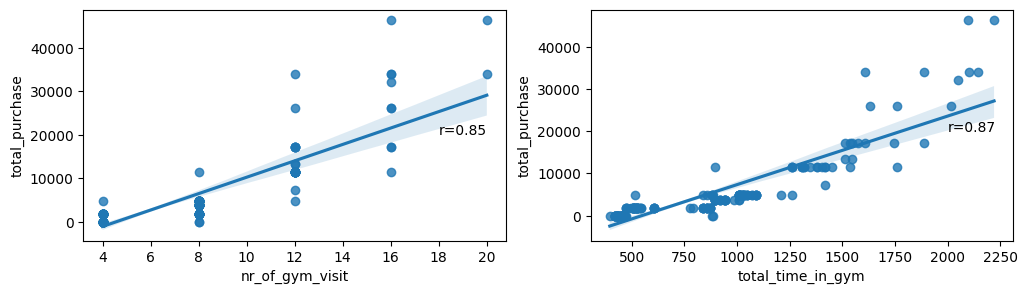

In [58]:
## plotting the avg expenditures
fig2,ax2=plt.subplots(1,2, figsize=(12,3))
sns.regplot(data=df_con[['total_purchase', 'nr_of_gym_visit']], x='nr_of_gym_visit', y= 'total_purchase', ax=ax2[0])
slope, intercept, r_value, p_value, std_err = stats.linregress(df_con['nr_of_gym_visit'], df_con['total_purchase'])
ax2[0].text(18, 20000,'r='+str(r_value.round(2)))
sns.regplot(data=df_con[['total_purchase', 'total_time_in_gym']], x='total_time_in_gym', y= 'total_purchase', ax=ax2[1])
slope, intercept, r_value, p_value, std_err = stats.linregress(df_con['total_time_in_gym'], df_con['total_purchase'])
ax2[1].text(2000, 20000,'r='+str(r_value.round(2)))

In [59]:
# detailed analysis on the purchase history
df_exp=pd.read_excel(xls, sheet_name="purchase")
df_exp.head(20)

,order_nr,user_id,item_id,price
0,1,2,4,3800
1,2,2,6,980
2,3,3,4,3800
3,4,3,6,980
4,5,5,12,1900
5,6,6,12,1900
6,7,7,4,3800
7,8,7,6,980
8,9,7,7,2500
9,10,7,8,4200


In [60]:
print(len(df_exp))

365


In [61]:
## to remove the bias, only show unique, confirming that there is no recurrent purchases by the same user
len(df_exp.drop_duplicates(subset=["user_id", "item_id"], keep="last"))

365

In [62]:
## check which item was purchased by most users
df_exp['item_id'].value_counts()

item_id
4     99
6     78
12    48
7     38
8     37
11    17
10    16
14    10
9      9
13     6
1      2
2      2
3      2
5      1
Name: count, dtype: int64

In [64]:
## check which item ID corresponds to which item
df_itm=pd.read_excel(xls, sheet_name="item_names")
df_itm

,item_id,item_name,category,price,release_date
0,1,Tシャツ,ウェア,2800,2023-12-01
1,2,パンツ,ウェア,3800,2023-12-01
2,3,ランニングシューズ,ウェア,5800,2023-12-01
3,4,プロテイン(1kg),サプリメント,3800,2023-12-01
4,5,プロテイン(3kg),サプリメント,9800,2023-12-01
5,6,プロテインシェイカー,サプリメント,980,2023-12-01
6,7,マルチビタミン,サプリメント,2500,2023-12-01
7,8,EAA,サプリメント,4200,2023-12-01
8,9,クレアチン,サプリメント,1900,2023-12-01
9,10,グルタミン,サプリメント,1900,2023-12-01


In [65]:
counts_df=df_exp['item_id'].value_counts()

In [66]:
## show top 3 items
for i in counts_df.index[:3]:
    print(df_itm.loc[df_itm['item_id'] == i])

   item_id   item_name category  price release_date
3        4  プロテイン(1kg)   サプリメント   3800   2023-12-01
   item_id   item_name category  price release_date
5        6  プロテインシェイカー   サプリメント    980   2023-12-01
    item_id item_name category  price release_date
11       12    腹筋ローラー      グッズ   1900   2023-12-01


# Make predictive model whether a user would keep the subscription or not.

In [67]:
df_con.columns

Index(['user_id', 'age', 'sex', 'area', 'registration_date',
       'membership_renewal', 'total_purchase', 'aim', 'aerobic_excercise',
       'calorie_cut', 'mentorship', 'nr_of_gym_visit', 'total_time_in_gym',
       'body_weight', 'body_fat', 'muscle_mass', 'aerobic_excercise(kcal/min)',
       'aerobic_excercise(kcal/visit)', 'stay_time_per_visit'],
      dtype='object')

In [68]:
## check if df has NaN value
df_con.loc[df_con.isnull().any(axis=1)]

,user_id,age,sex,area,registration_date,membership_renewal,total_purchase,aim,aerobic_excercise,calorie_cut,mentorship,nr_of_gym_visit,total_time_in_gym,body_weight,body_fat,muscle_mass,aerobic_excercise(kcal/min),aerobic_excercise(kcal/visit),stay_time_per_visit
109,110,27,2,8,2024-02-22,0,0,2,925.369018,NaN,1.0,4,420,-0.049223,-0.003552,-0.33019,2.203260,231.342255,105.0
133,134,29,1,8,2024-03-04,1,3800,1,331.123211,7.0,NaN,8,944,1.145360,-0.001203,0.60000,0.350766,41.390401,118.0


In [73]:
from sklearn.model_selection import train_test_split


# Define features (X) and target variable (y) for logistic regression. Remove columns that include NaN values, as well as unnecessary columns
X = df_con.drop(columns=['user_id', 'registration_date','membership_renewal', 'calorie_cut','mentorship',
                         'aerobic_excercise(kcal/min)','aerobic_excercise(kcal/visit)', 'stay_time_per_visit'])  
y = df_con['membership_renewal']  # Target variable

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}, Testing set: {X_test.shape}")

Training set: (160, 11), Testing set: (40, 11)


In [74]:
X.loc[df_con.isnull().any(axis=1)]

,age,sex,area,total_purchase,aim,aerobic_excercise,nr_of_gym_visit,total_time_in_gym,body_weight,body_fat,muscle_mass
109,27,2,8,0,2,925.369018,4,420,-0.049223,-0.003552,-0.33019
133,29,1,8,3800,1,331.123211,8,944,1.145360,-0.001203,0.60000


In [75]:
# Create and train the model, logistic regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)
#model.fit(X_train, y_train)

In [76]:
## cross validation, keep the data splitting the same (80 % for train, 20 % for test)
from sklearn.model_selection import cross_validate
scoring = ['precision_macro', 'recall_macro', 'f1_macro', 'accuracy']
results = cross_validate(model, X, y, cv=5, scoring=scoring, return_train_score=True)

In [77]:
pd.DataFrame(results)

,fit_time,score_time,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy
0,0.186780,0.003757,0.982759,0.940580,0.958333,0.924107,0.969489,0.931789,0.975,0.94375
1,0.136977,0.003685,0.847578,0.971498,0.863095,0.953869,0.854545,0.962105,0.875,0.96875
2,0.150354,0.004033,1.000000,0.935737,1.000000,0.913690,1.000000,0.923722,1.000,0.93750
3,0.151893,0.003614,0.857367,0.960717,0.839286,0.949405,0.847445,0.954811,0.875,0.96250
4,0.145375,0.003003,0.982759,0.956039,0.958333,0.938988,0.969489,0.946947,0.975,0.95625


In [78]:
pd.DataFrame(results)[['test_f1_macro', 'train_f1_macro', 'test_accuracy', 'train_accuracy']]

,test_f1_macro,train_f1_macro,test_accuracy,train_accuracy
0,0.969489,0.931789,0.975,0.94375
1,0.854545,0.962105,0.875,0.96875
2,1.000000,0.923722,1.000,0.93750
3,0.847445,0.954811,0.875,0.96250
4,0.969489,0.946947,0.975,0.95625


In [79]:
# Create and train the model, logistic regression, final model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [80]:
# Predict survival on the test set
y_pred = model.predict(X_test)

# Get probability scores
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probabilities for class 1 (kept subscription)

In [81]:
print(y_pred)
print(y_pred_proba)

[0 0 0 0 1 0 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0
 1 0 0]
[0.1525969  0.1268923  0.01003172 0.3922863  0.76827457 0.14218989
 0.13030495 0.9632422  0.02794926 1.         0.03076971 0.00932718
 0.01561907 0.71525744 0.00200894 0.00124954 0.71918855 0.00172978
 0.03773004 0.00346948 0.00328874 0.68241141 0.03064694 0.64290025
 0.00829027 0.03666409 0.00860504 0.19441618 0.00393529 0.00241687
 0.15740504 0.00670833 0.10115733 0.80218384 0.99998245 0.01893531
 0.12467024 0.99999467 0.00866939 0.0608646 ]


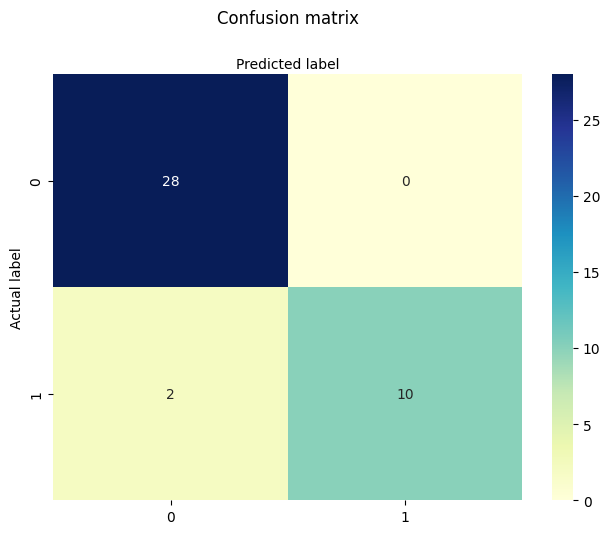

In [82]:
from sklearn import metrics

cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

plt.Text(0.5,257.44,'Predicted label');

In [83]:
#stats of final model
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      1.00      0.97        28
           1       1.00      0.83      0.91        12

    accuracy                           0.95        40
   macro avg       0.97      0.92      0.94        40
weighted avg       0.95      0.95      0.95        40



# Predictive model for price

In [84]:
## models for price
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate

X1 = df_con.drop(columns=['total_purchase', 
                         'user_id', 'registration_date','membership_renewal', 'calorie_cut','mentorship',
                         'aerobic_excercise(kcal/min)','aerobic_excercise(kcal/visit)', 'stay_time_per_visit'])   # All columns except unnecessary columns
y1 = df_con['total_purchase']  # Target variable

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# Create and train the model
model2 = LinearRegression()  # Increase iterations if needed
scoring = {
    'r2': 'r2',
    'nmae': 'neg_mean_absolute_error'
}
results2 = cross_validate(model2, X1, y1, cv=5, scoring=scoring, return_train_score=True)
pd.DataFrame(results2)

,fit_time,score_time,test_r2,train_r2,test_nmae,train_nmae
0,0.012635,0.001514,0.784864,0.791968,-2415.322030,-2664.658685
1,0.000887,0.000645,0.818357,0.783779,-2831.451799,-2502.969597
2,0.000777,0.000754,-0.081011,0.790227,-3739.134350,-2416.108661
3,0.000884,0.000656,0.712185,0.808155,-2932.415926,-2369.785502
4,0.000748,0.000606,0.676757,0.812389,-2609.179971,-2481.933302


In [127]:
X1

,年齢,性別,居住エリア,継続フラグ,目的,有酸素運動,ジム利用回数,ジム合計滞在時間,体重,体脂肪率,筋肉量
0,29,1,3,0,1,335.082824,4,468,0.562831,0.004389,-0.352464
1,32,2,8,1,2,1600.000000,8,880,-0.055478,-0.010000,0.248310
2,30,1,5,0,3,380.559631,8,1072,1.038801,0.005267,0.239278
3,29,2,3,0,2,699.763166,4,396,0.913511,-0.000774,0.058059
4,24,1,8,0,1,484.871381,8,776,0.059202,0.005093,0.182056
...,...,...,...,...,...,...,...,...,...,...,...
195,24,2,8,0,2,762.949694,8,840,-0.029638,0.005138,-0.122330
196,31,2,5,0,2,733.415806,4,508,-0.113744,0.009864,-0.025370
197,29,1,3,1,1,522.263410,12,1608,-0.295031,-0.002670,0.500000
198,23,1,5,0,1,233.531440,4,504,0.176865,0.008567,0.143348


In [85]:
## models for price
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate

X2 = df_con.drop(columns=['total_purchase', 'user_id', 'registration_date','membership_renewal', 'calorie_cut','mentorship',
                         'aerobic_excercise(kcal/min)','aerobic_excercise(kcal/visit)', 'stay_time_per_visit'])

y2 = df_con['total_purchase']

# Create and train the model
model3 = LinearRegression()  # Increase iterations if needed
scoring = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error'
}
results3 = cross_validate(model3, X2, y2, cv=5, scoring=scoring, return_train_score=True)
pd.DataFrame(results3)

,fit_time,score_time,test_r2,train_r2,test_mae,train_mae
0,0.003294,0.002176,0.784864,0.791968,-2415.322030,-2664.658685
1,0.001845,0.001434,0.818357,0.783779,-2831.451799,-2502.969597
2,0.001479,0.001197,-0.081011,0.790227,-3739.134350,-2416.108661
3,0.000868,0.000629,0.712185,0.808155,-2932.415926,-2369.785502
4,0.000734,0.000594,0.676757,0.812389,-2609.179971,-2481.933302


In [146]:
pd.DataFrame(results2)

,fit_time,score_time,test_r2,train_r2,test_mae,train_mae
0,0.015579,0.001067,0.768371,0.781197,-2701.951599,-2829.889795
1,0.000755,0.000563,0.826472,0.768801,-2702.492823,-2723.089439
2,0.000614,0.000521,0.030170,0.776021,-3845.143914,-2516.849056
3,0.000602,0.000529,0.742287,0.789755,-2873.244998,-2623.160153
4,0.000592,0.000494,0.654151,0.809001,-2781.074650,-2534.877575


## Predictive model, random forest

In [86]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(random_state=42)
results3_2 = cross_validate(model_rf, X1, y1, cv=5, scoring=scoring, return_train_score=True)
pd.DataFrame(results3_2)

,fit_time,score_time,test_r2,train_r2,test_mae,train_mae
0,0.060875,0.004136,0.767849,0.976483,-862.730,-471.73625
1,0.057736,0.003758,0.880481,0.976914,-1269.615,-396.47250
2,0.058006,0.003772,0.890409,0.973075,-992.110,-440.57750
3,0.058989,0.003668,0.834052,0.976892,-1134.520,-449.15625
4,0.060234,0.004199,0.745321,0.979251,-1443.910,-383.68250


In [87]:
## grid search for optimum hyperparameters
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators':[100,200,300, 400, 500, 600, 800,1000], 
    'max_depth':[1,2,3,4,5,6],
    'min_samples_leaf':[10,20,25,50,100],
}
grid_search = GridSearchCV(
    estimator=model_rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X1_train, y1_train)

print("Best parameters:", grid_search.best_params_)

Fitting 3 folds for each of 240 candidates, totalling 720 fits
Best parameters: {'max_depth': 3, 'min_samples_leaf': 10, 'n_estimators': 100}


In [88]:
## cross-validation with optimum hyperparameters
model_rf = RandomForestRegressor(
    n_estimators=100, 
    max_depth=3,  
    min_samples_leaf=10, 
    random_state=42
)
results3_2_mod = cross_validate(model_rf, X1, y1, cv=5, scoring=scoring, return_train_score=True)
pd.DataFrame(results3_2_mod)

,fit_time,score_time,test_r2,train_r2,test_mae,train_mae
0,0.073647,0.005749,0.825561,0.809203,-1251.925696,-1520.349032
1,0.059134,0.004099,0.765781,0.799534,-2033.077160,-1351.659193
2,0.053164,0.003858,0.794523,0.805064,-1252.989611,-1384.485637
3,0.052971,0.004141,0.834857,0.789712,-1536.988585,-1532.703344
4,0.052456,0.003952,0.732809,0.830202,-1721.025174,-1407.983495


In [89]:
pd.DataFrame(results3_2_mod)[['test_r2', 'train_r2']]

,test_r2,train_r2
0,0.825561,0.809203
1,0.765781,0.799534
2,0.794523,0.805064
3,0.834857,0.789712
4,0.732809,0.830202


In [ ]:
## improvement as the difference between test_r2 and train_r2 are much smaller than linear regression model

In [90]:
## make final model

model_rf = RandomForestRegressor(
    n_estimators=100, 
    max_depth=3,  
    min_samples_leaf=10,
    random_state=42
)
model_rf.fit(X1_train, y1_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [91]:
# Predict survival on the test set
y1_pred = model_rf.predict(X1_test)

In [92]:
print(y1_pred)

#print(y_pred_proba)

[ 1523.58575054  4684.47796644  1523.58575054  4624.91709881
  4681.67101385  4654.15086893  1523.58575054 19203.1827344
  5492.39242591 23639.18758793  1523.58575054   561.73970254
   561.73970254  4463.87715379   561.73970254   739.21058916
  5508.95289643   561.73970254  4776.74261563   561.73970254
  1523.58575054 11962.57398278   561.73970254  4558.54796346
  1197.62660273  4482.72143272   561.73970254  1670.46973368
  4740.93032304  1523.58575054  4616.4468515   1523.58575054
  1523.58575054  4560.16651234 11849.68402552  1523.58575054
  1523.58575054 23572.4494927    561.73970254  4291.4982702 ]


In [93]:
from sklearn.metrics import r2_score
y1_r2=r2_score(y1_test, y1_pred)

In [94]:
print(y1_r2)

0.8621146407523658


In [95]:
print(y1_test)

95      1900
15      4780
30      1900
158     4780
128     3800
115     4780
69      1900
170    17180
174     4780
45     33980
66      4780
182        0
165        0
78      3800
186        0
177        0
56      4780
152        0
82      4780
68         0
124     1900
16      7280
148        0
93      3800
65      1900
60         0
84         0
67      1900
125     4780
132     1900
9       3800
18      1900
55      1900
75      3800
150    11480
104     1900
135     4780
137    33980
164        0
76         0
Name: total_purchase, dtype: int64


Text(0, 0.5, 'total_purchase_predict')

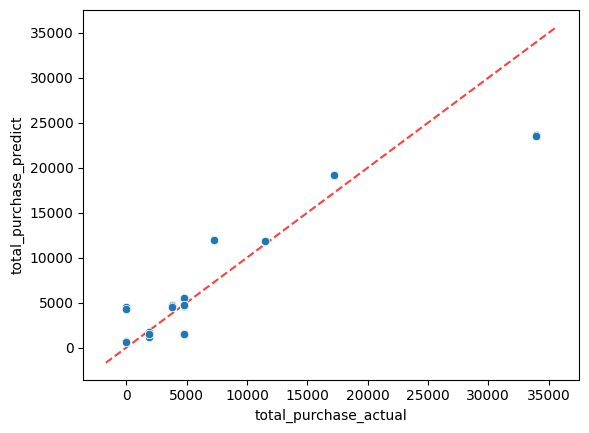

In [97]:
#plot 際の累計購入金額 vs 予測累計購入金額
ax=sns.scatterplot(x=y1_test, y=y1_pred)
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]
ax.plot(lims, lims, '--r', alpha=0.75, zorder=0)
plt.xlabel('total_purchase_actual')
plt.ylabel('total_purchase_predict')

In [ ]:
## improvement in the model can be done to make the prediction on the higher end better